In [10]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
# Paths
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_ROOT = PROJECT_ROOT / "data" / "modern_dataset"

TRAIN_DIR = DATA_ROOT / "Train"
VAL_DIR = DATA_ROOT / "Validation"
TEST_DIR = DATA_ROOT / "Test"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

PROJECT_ROOT: C:\Users\zakiz\Downloads\COMP-487-Project-1-main
DATA_ROOT: C:\Users\zakiz\Downloads\COMP-487-Project-1-main\data\modern_dataset
Train exists: True
Validation exists: True
Test exists: True


In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 10923 files belonging to 2 classes.
Found 2341 files belonging to 2 classes.
Found 2635 files belonging to 2 classes.


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [14]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [15]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

In [16]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 132s 324ms/step - accuracy: 0.9239 - loss: 0.1929 - val_accuracy: 0.9697 - val_loss: 0.0921
Epoch 2/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 92s 269ms/step - accuracy: 0.9666 - loss: 0.0933 - val_accuracy: 0.9761 - val_loss: 0.0704
Epoch 3/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 92s 269ms/step - accuracy: 0.9742 - loss: 0.0761 - val_accuracy: 0.9808 - val_loss: 0.0587
Epoch 4/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 93s 273ms/step - accuracy: 0.9732 - loss: 0.0751 - val_accuracy: 0.9791 - val_loss: 0.0598
Epoch 5/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 94s 276ms/step - accuracy: 0.9760 - loss: 0.0703 - val_accuracy: 0.9761 - val_loss: 0.0668


In [18]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 19s 228ms/step - accuracy: 0.9784 - loss: 0.0631
Test accuracy: 0.9783681035041809


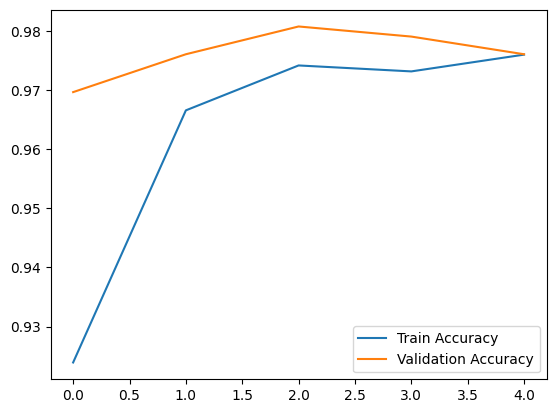

In [19]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

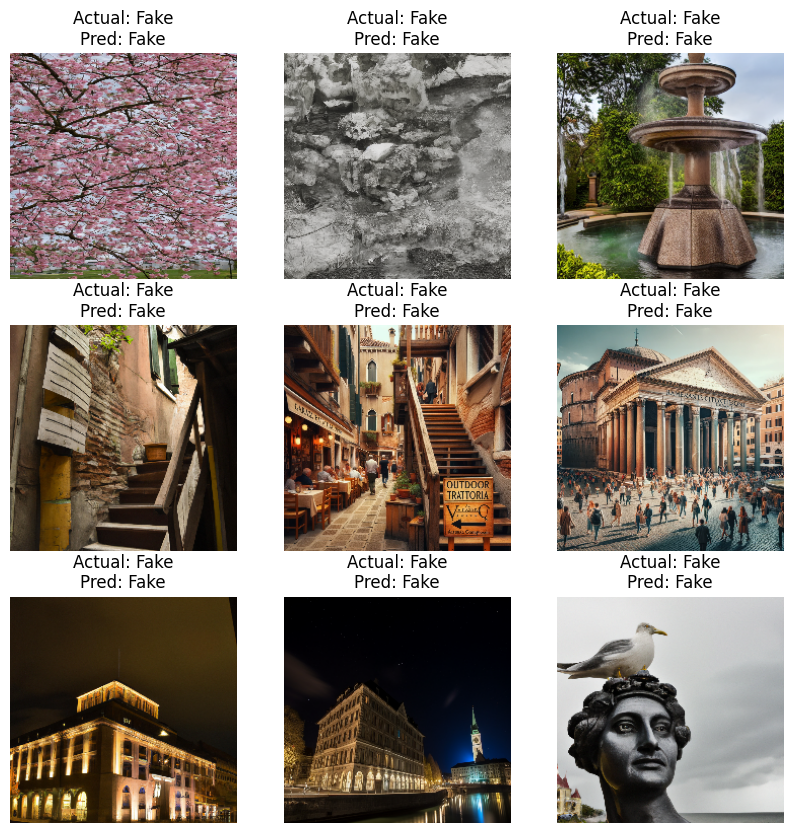

In [20]:
class_names = ['Fake', 'Real']

plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        img = images[i]
        label = int(labels[i].numpy())

        pred = model.predict(tf.expand_dims(img, axis=0), verbose=0)
        pred_label = 1 if pred[0][0] > 0.5 else 0

        plt.imshow(img.numpy().astype("uint8"))
        plt.title(f"Actual: {class_names[label]}\nPred: {class_names[pred_label]}")
        plt.axis("off")

plt.show()